# DEPM Replication — Full Paper Methodology

Replicating **all experiments** from:
> *Prediction of electricity consumption using an innovative deep energy predictor model* (Ragupathi et al., Energy Reports 12, 2024)

**Experiments:** Tables 1–6, Confusion Matrix, ROC Curves, all comparisons.

## 1. Imports

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, time, warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve, classification_report
from xgboost import XGBClassifier
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


## 2. Data Collection

UCI Household Electric Power Consumption dataset (~2M minute-level readings, 47 months).

In [2]:
df = pd.read_csv('../data/household_power_consumption.txt', sep=';', low_memory=False, na_values=['?'])
num_cols = ['Global_active_power','Global_reactive_power','Voltage','Global_intensity','Sub_metering_1','Sub_metering_2','Sub_metering_3']
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')
df.drop(columns=['Date','Time'], inplace=True)
df.set_index('Datetime', inplace=True)
print(f"Raw shape: {df.shape}")
print(f"Missing values:\n{df.isnull().sum()}")
df.head()

Raw shape: (2075259, 7)
Missing values:
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


## 3. Data Preprocessing
### 3.1 Data Cleaning — Median Imputation (Paper §3.2.1)

In [3]:
print("Before imputation:")
print(df.isnull().sum())
for c in num_cols:
    df[c].fillna(df[c].median(), inplace=True)
print("\nAfter imputation:")
print(df.isnull().sum())

Before imputation:
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

After imputation:
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64


### 3.2 Outlier Detection — IQR Method (Paper §3.2.2)

In [4]:
print(f"Shape before IQR: {df.shape}")
for c in num_cols:
    Q1 = df[c].quantile(0.25)
    Q3 = df[c].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = len(df)
    df = df[(df[c] >= lower) & (df[c] <= upper)]
    removed = before - len(df)
    if removed > 0:
        print(f"  {c}: removed {removed:,} outliers (bounds: [{lower:.3f}, {upper:.3f}])")
print(f"Shape after IQR:  {df.shape}")

Shape before IQR: (2075259, 7)
  Global_active_power: removed 96,742 outliers (bounds: [-1.505, 3.335])
  Global_reactive_power: removed 35,623 outliers (bounds: [-0.162, 0.398])
  Voltage: removed 54,898 outliers (bounds: [233.795, 248.475])
  Global_intensity: removed 19,238 outliers (bounds: [-5.500, 12.900])
  Sub_metering_1: removed 99,646 outliers (bounds: [0.000, 0.000])
  Sub_metering_2: removed 30,032 outliers (bounds: [-1.500, 2.500])
Shape after IQR:  (1739080, 7)


### 3.3 Data Transformation (Paper §3.2.3)

Hourly resampling + standardization.

Hourly shape: (33528, 7)
Threshold (median GAP): 0.6121 kW
Class balance: 50.00% High


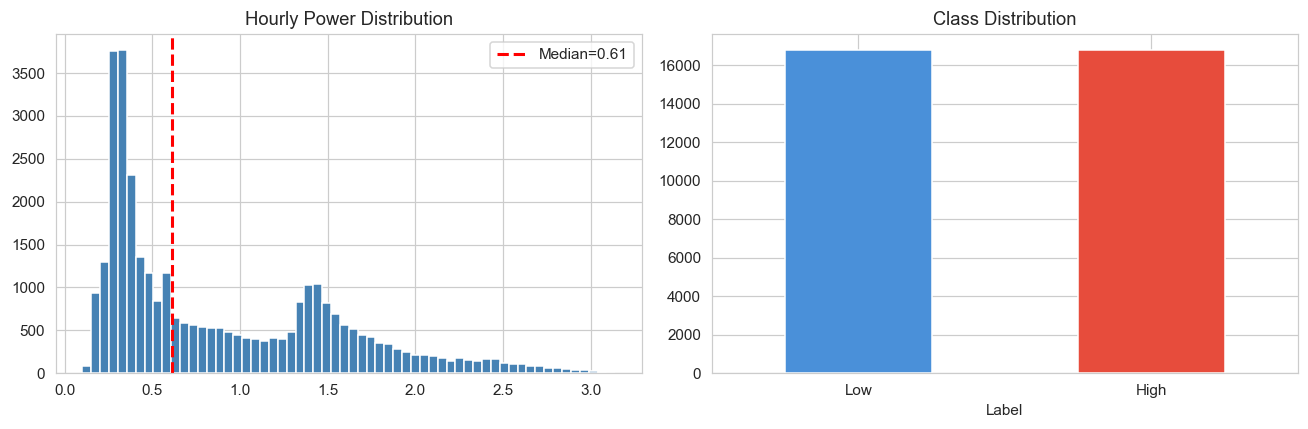

In [5]:
df_h = df.resample('1h').mean().dropna()
print(f"Hourly shape: {df_h.shape}")

# Create binary target: High (1) / Low (0) based on median of Global_active_power
threshold = df_h['Global_active_power'].median()
df_h['Label'] = (df_h['Global_active_power'] > threshold).astype(int)
print(f"Threshold (median GAP): {threshold:.4f} kW")
print(f"Class balance: {df_h['Label'].mean():.2%} High")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_h['Global_active_power'], bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(threshold, color='red', ls='--', lw=2, label=f'Median={threshold:.2f}')
axes[0].set_title('Hourly Power Distribution'); axes[0].legend()
df_h['Label'].value_counts().plot.bar(ax=axes[1], color=['#4a90d9','#e74c3c'], edgecolor='white')
axes[1].set_xticklabels(['Low','High'], rotation=0); axes[1].set_title('Class Distribution')
plt.tight_layout(); plt.show()

### 3.4 Feature Engineering (Paper §3.2.4)

- Temporal features (hour, day of week, month, season, weekend)
- Lagged consumption values
- Rolling statistics (mean, min, max)
- Interaction terms
- Aggregated features (daily, weekly)
- Holiday indicator

In [6]:
# Temporal features
df_h['Hour'] = df_h.index.hour
df_h['DayOfWeek'] = df_h.index.dayofweek
df_h['Month'] = df_h.index.month
df_h['Season'] = df_h['Month'].map({12:0,1:0,2:0,3:1,4:1,5:1,6:2,7:2,8:2,9:3,10:3,11:3})
df_h['IsWeekend'] = (df_h.index.dayofweek >= 5).astype(int)

# Lagged features
for lag in [1, 2, 3, 6, 12, 24]:
    df_h[f'GAP_lag_{lag}'] = df_h['Global_active_power'].shift(lag)

# Rolling statistics
for win in [6, 12, 24, 168]:
    df_h[f'GAP_roll_mean_{win}'] = df_h['Global_active_power'].rolling(win).mean()
    df_h[f'GAP_roll_std_{win}'] = df_h['Global_active_power'].rolling(win).std()
    df_h[f'GAP_roll_min_{win}'] = df_h['Global_active_power'].rolling(win).min()
    df_h[f'GAP_roll_max_{win}'] = df_h['Global_active_power'].rolling(win).max()

# Interaction terms
df_h['GAP_x_Hour'] = df_h['Global_active_power'] * df_h['Hour']
df_h['GAP_x_DayOfWeek'] = df_h['Global_active_power'] * df_h['DayOfWeek']
df_h['Intensity_x_Voltage'] = df_h['Global_intensity'] * df_h['Voltage']
df_h['SubTotal'] = df_h['Sub_metering_1'] + df_h['Sub_metering_2'] + df_h['Sub_metering_3']

# Holiday indicator (French public holidays approximation)
french_holidays = pd.to_datetime([
    '2007-01-01','2007-05-01','2007-07-14','2007-11-01','2007-12-25',
    '2008-01-01','2008-05-01','2008-07-14','2008-11-01','2008-12-25',
    '2009-01-01','2009-05-01','2009-07-14','2009-11-01','2009-12-25',
    '2010-01-01','2010-05-01','2010-07-14','2010-11-01','2010-12-25',
])
df_h['IsHoliday'] = df_h.index.normalize().isin(french_holidays).astype(int)

# Drop rows with NaN from lagging/rolling
df_h.dropna(inplace=True)

# Features = everything except target-related columns
exclude = ['Global_active_power', 'Label']
feature_cols = [c for c in df_h.columns if c not in exclude]
print(f"Engineered features ({len(feature_cols)}):")
for i, c in enumerate(feature_cols):
    print(f"  {i+1:2d}. {c}")
print(f"\nSamples: {len(df_h):,}")

Engineered features (38):
   1. Global_reactive_power
   2. Voltage
   3. Global_intensity
   4. Sub_metering_1
   5. Sub_metering_2
   6. Sub_metering_3
   7. Hour
   8. DayOfWeek
   9. Month
  10. Season
  11. IsWeekend
  12. GAP_lag_1
  13. GAP_lag_2
  14. GAP_lag_3
  15. GAP_lag_6
  16. GAP_lag_12
  17. GAP_lag_24
  18. GAP_roll_mean_6
  19. GAP_roll_std_6
  20. GAP_roll_min_6
  21. GAP_roll_max_6
  22. GAP_roll_mean_12
  23. GAP_roll_std_12
  24. GAP_roll_min_12
  25. GAP_roll_max_12
  26. GAP_roll_mean_24
  27. GAP_roll_std_24
  28. GAP_roll_min_24
  29. GAP_roll_max_24
  30. GAP_roll_mean_168
  31. GAP_roll_std_168
  32. GAP_roll_min_168
  33. GAP_roll_max_168
  34. GAP_x_Hour
  35. GAP_x_DayOfWeek
  36. Intensity_x_Voltage
  37. SubTotal
  38. IsHoliday

Samples: 33,361


### 3.5 Data Reduction — PCA (Paper §3.3)

PCA: 38 features -> 20 components (95% variance)
Explained variance per component: [0.33394174 0.11970325 0.06916419 0.05564453 0.05246602 0.03937902
 0.03814466 0.03534958 0.03038085 0.02637093 0.02587414 0.0207986
 0.01975808 0.01648861 0.01398342 0.01206677 0.01135839 0.01080246
 0.00964265 0.00890255]


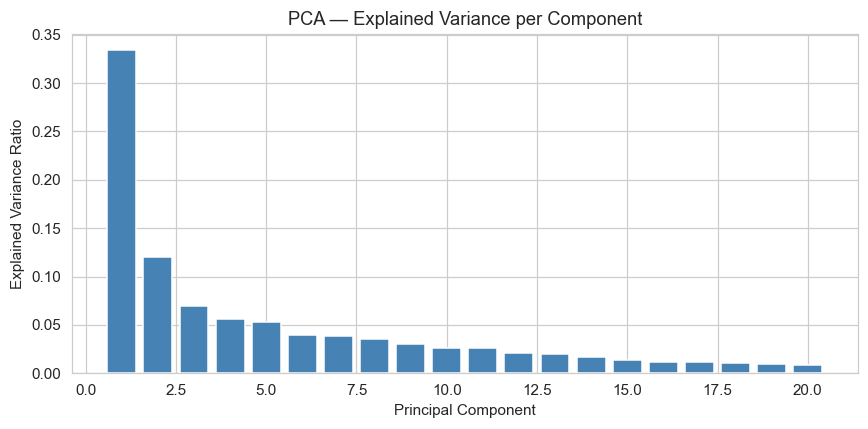

In [7]:
X_raw = df_h[feature_cols].values
y = df_h['Label'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA: {X_scaled.shape[1]} features -> {X_pca.shape[1]} components (95% variance)")
print(f"Explained variance per component: {pca.explained_variance_ratio_}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_, color='steelblue')
ax.set_xlabel('Principal Component'); ax.set_ylabel('Explained Variance Ratio')
ax.set_title('PCA — Explained Variance per Component')
plt.tight_layout(); plt.show()

## 4. Train/Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Train class balance: {y_train.mean():.2%} High")
print(f"Test  class balance: {y_test.mean():.2%} High")

Train: (26688, 20) | Test: (6673, 20)
Train class balance: 49.88% High
Test  class balance: 49.89% High


## 5. Cascaded ResNet Feature Extraction (Paper §3.4)

1D Residual Network that extracts higher-level features from PCA components.

In [9]:
class ResidualBlock1D(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim), nn.BatchNorm1d(dim), nn.ReLU(),
            nn.Linear(dim, dim), nn.BatchNorm1d(dim))
        self.relu = nn.ReLU()
    def forward(self, x):
        return self.relu(self.block(x) + x)

class CascadedResNet(nn.Module):
    def __init__(self, input_dim, hidden=128, n_blocks=4, out_dim=32):
        super().__init__()
        self.proj = nn.Sequential(nn.Linear(input_dim, hidden), nn.BatchNorm1d(hidden), nn.ReLU())
        self.blocks = nn.Sequential(*[ResidualBlock1D(hidden) for _ in range(n_blocks)])
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(hidden, out_dim)
    def forward(self, x):
        x = self.proj(x)
        x = self.blocks(x)
        return self.fc(x)

# Train ResNet as autoencoder to learn features
resnet = CascadedResNet(X_train.shape[1], hidden=128, n_blocks=4, out_dim=32).to(device)
decoder = nn.Linear(32, X_train.shape[1]).to(device)

opt_ae = optim.Adam(list(resnet.parameters()) + list(decoder.parameters()), lr=1e-3)
loss_fn = nn.MSELoss()

train_t = torch.FloatTensor(X_train).to(device)
test_t = torch.FloatTensor(X_test).to(device)
ds = TensorDataset(train_t, train_t)
loader = DataLoader(ds, batch_size=256, shuffle=True)

print("Training Cascaded ResNet for feature extraction...")
for epoch in range(30):
    total_loss = 0
    for xb, _ in loader:
        z = resnet(xb)
        xhat = decoder(z)
        loss = loss_fn(xhat, xb)
        opt_ae.zero_grad(); loss.backward(); opt_ae.step()
        total_loss += loss.item() * xb.size(0)
    if (epoch+1) % 10 == 0:
        print(f"  Epoch {epoch+1:02d} | Recon Loss: {total_loss/len(train_t):.6f}")

resnet.eval()
with torch.no_grad():
    Z_train = resnet(train_t).cpu().numpy()
    Z_test = resnet(test_t).cpu().numpy()
print(f"\nResNet features: {Z_train.shape[1]}-dim extracted")
print(f"Combined features: PCA({X_train.shape[1]}) + ResNet({Z_train.shape[1]}) = {X_train.shape[1]+Z_train.shape[1]}")

# Combined feature set
X_train_full = np.hstack([X_train, Z_train])
X_test_full = np.hstack([X_test, Z_test])

Training Cascaded ResNet for feature extraction...
  Epoch 10 | Recon Loss: 0.030256
  Epoch 20 | Recon Loss: 0.023277
  Epoch 30 | Recon Loss: 0.019351

ResNet features: 32-dim extracted
Combined features: PCA(20) + ResNet(32) = 52


## 6. Helper Functions

In [10]:
def eval_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred)
    }

class FlexDNN(nn.Module):
    def __init__(self, input_dim, n_layers=5, neurons=128, activation='relu', dropout=0.3):
        super().__init__()
        act_map = {
            'relu': nn.ReLU(), 'sigmoid': nn.Sigmoid(), 'tanh': nn.Tanh(),
            'leakyrelu': nn.LeakyReLU(), 'elu': nn.ELU(), 'selu': nn.SELU(),
            'softplus': nn.Softplus(), 'swish': nn.SiLU(), 'hardsigmoid': nn.Hardsigmoid(),
        }
        act = act_map.get(activation, nn.ReLU())
        layers = [nn.Linear(input_dim, neurons), nn.BatchNorm1d(neurons), act, nn.Dropout(dropout)]
        for _ in range(n_layers - 2):
            layers += [nn.Linear(neurons, neurons), nn.BatchNorm1d(neurons), act, nn.Dropout(dropout)]
        layers += [nn.Linear(neurons, 1), nn.Sigmoid()]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x).squeeze(-1)
    def extract_features(self, x):
        for layer in list(self.net.children())[:-2]:
            x = layer(x)
        return x

def train_dnn(X_tr, y_tr, X_te, y_te, n_layers=5, neurons=128, activation='relu',
              optimizer_name='adam', lr=1e-3, batch_size=64, epochs=30, verbose=False):
    model = FlexDNN(X_tr.shape[1], n_layers, neurons, activation).to(device)
    opt_map = {
        'adam': optim.Adam, 'sgd': optim.SGD, 'rmsprop': optim.RMSprop,
        'adagrad': optim.Adagrad, 'adadelta': optim.Adadelta,
        'adamax': optim.Adamax, 'nadam': optim.NAdam, 'asgd': optim.ASGD,
    }
    OptClass = opt_map.get(optimizer_name.lower(), optim.Adam)
    optimizer = OptClass(model.parameters(), lr=lr)
    criterion = nn.BCELoss()
    
    ds = TensorDataset(torch.FloatTensor(X_tr), torch.FloatTensor(y_tr))
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True)
    
    t0 = time.time()
    for epoch in range(epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward(); optimizer.step()
    elapsed = time.time() - t0
    
    model.eval()
    with torch.no_grad():
        probs = model(torch.FloatTensor(X_te).to(device)).cpu().numpy()
    preds = (probs > 0.5).astype(int)
    metrics = eval_metrics(y_te, preds)
    metrics['Time(s)'] = f'{elapsed:.1f}'
    if verbose:
        print(f"  Acc={metrics['Accuracy']:.4f} P={metrics['Precision']:.4f} R={metrics['Recall']:.4f} F1={metrics['F1-Score']:.4f} ({elapsed:.1f}s)")
    return model, metrics, probs

def plot_table(df, title, figsize=(10,5)):
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    df[['Accuracy','F1-Score']].plot.barh(ax=axes[0], color=['#2196F3','#FF5722'])
    axes[0].set_title(f'{title} — Accuracy & F1'); axes[0].set_xlim(0.5, 1.0)
    df[['Precision','Recall']].plot.barh(ax=axes[1], color=['#4CAF50','#9C27B0'])
    axes[1].set_title(f'{title} — Precision & Recall'); axes[1].set_xlim(0.5, 1.0)
    plt.tight_layout(); plt.show()

---
# Experiments
---

## Experiment 1 — Activation Functions (Paper Table 1)

Training DNN with different activation functions...

  sigmoid         →   Acc=0.9754 P=0.9817 R=0.9688 F1=0.9752 (75.0s)
  tanh            →   Acc=0.9777 P=0.9775 R=0.9778 F1=0.9776 (74.9s)
  leakyrelu       →   Acc=0.9783 P=0.9804 R=0.9760 F1=0.9782 (74.8s)
  elu             →   Acc=0.9769 P=0.9798 R=0.9739 F1=0.9768 (72.8s)
  softplus        →   Acc=0.9753 P=0.9803 R=0.9700 F1=0.9751 (73.5s)
  swish           →   Acc=0.9765 P=0.9803 R=0.9724 F1=0.9763 (76.1s)
  selu            →   Acc=0.9747 P=0.9808 R=0.9682 F1=0.9745 (76.2s)
  hardsigmoid     →   Acc=0.9693 P=0.9924 R=0.9456 F1=0.9685 (76.2s)
  relu            →   Acc=0.9774 P=0.9801 R=0.9745 F1=0.9773 (76.1s)
  Proposed        →   Acc=0.9787 P=0.9854 R=0.9718 F1=0.9785 (127.3s)

  Table 1 — Activation Function Comparison (Our Results)
                    Accuracy  Precision  Recall  F1-Score
Activation                                               
Sigmoid                 0.98       0.98    0.97      0.98
Tanh                    

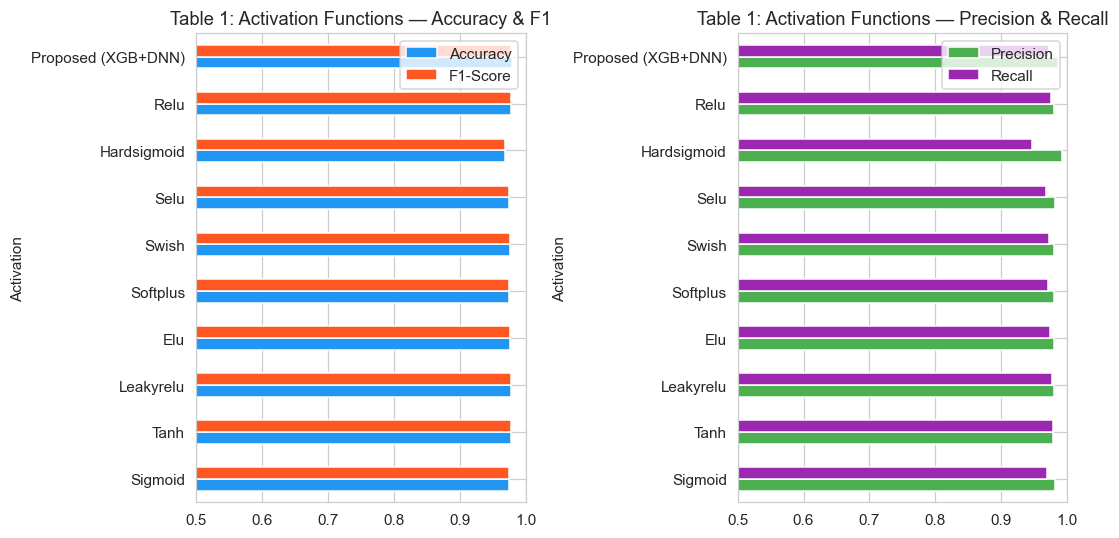

In [11]:
activations = ['sigmoid','tanh','leakyrelu','elu','softplus','swish','selu','hardsigmoid','relu']
act_results = []
print("Training DNN with different activation functions...\n")
for act in activations:
    print(f"  {act:15s}", end=" → ")
    _, m, _ = train_dnn(X_train_full, y_train, X_test_full, y_test, activation=act, epochs=30, batch_size=64, verbose=True)
    m['Activation'] = act.capitalize()
    act_results.append(m)

# Add proposed model result
print(f"  {'Proposed':15s}", end=" → ")
proposed_model, pm, proposed_probs = train_dnn(
    X_train_full, y_train, X_test_full, y_test,
    n_layers=5, neurons=128, activation='relu', optimizer_name='adam',
    lr=1e-3, batch_size=64, epochs=50, verbose=True)
pm['Activation'] = 'Proposed (XGB+DNN)'
act_results.append(pm)

table1 = pd.DataFrame(act_results).set_index('Activation')[['Accuracy','Precision','Recall','F1-Score']]
print("\n" + "="*70)
print("  Table 1 — Activation Function Comparison (Our Results)")
print("="*70)
print(table1.to_string(float_format='%.2f'))
plot_table(table1, 'Table 1: Activation Functions')

## Experiment 2 — Hyperparameter Tuning for DNN (Paper Table 2)

Hyperparameter tuning...

  Layers=3        →   Acc=0.9769 P=0.9841 R=0.9694 F1=0.9767 (54.2s)
  Layers=5        →   Acc=0.9748 P=0.9700 R=0.9799 F1=0.9749 (78.7s)
  Layers=7        →   Acc=0.9771 P=0.9874 R=0.9664 F1=0.9768 (96.6s)
  Neurons=64      →   Acc=0.9769 P=0.9786 R=0.9751 F1=0.9768 (75.0s)
  Neurons=128     →   Acc=0.9780 P=0.9804 R=0.9754 F1=0.9779 (76.2s)
  Neurons=256     →   Acc=0.9792 P=0.9770 R=0.9814 F1=0.9792 (79.5s)
  Act=ReLU        →   Acc=0.9732 P=0.9855 R=0.9603 F1=0.9728 (76.3s)
  Act=Sigmoid     →   Acc=0.9745 P=0.9867 R=0.9619 F1=0.9741 (76.8s)
  Opt=Adam        →   Acc=0.9754 P=0.9820 R=0.9685 F1=0.9752 (76.2s)
  Opt=SGD         →   Acc=0.9630 P=0.9930 R=0.9324 F1=0.9617 (68.6s)

  Table 2 — Hyperparameter Tuning Results (Our Results)
             Accuracy  Precision  Recall  F1-Score
Config                                            
Layers=3         0.98       0.98    0.97      0.98
Layers=5         0.97       0.97    0.98      0.97
Layers=7         0.98  

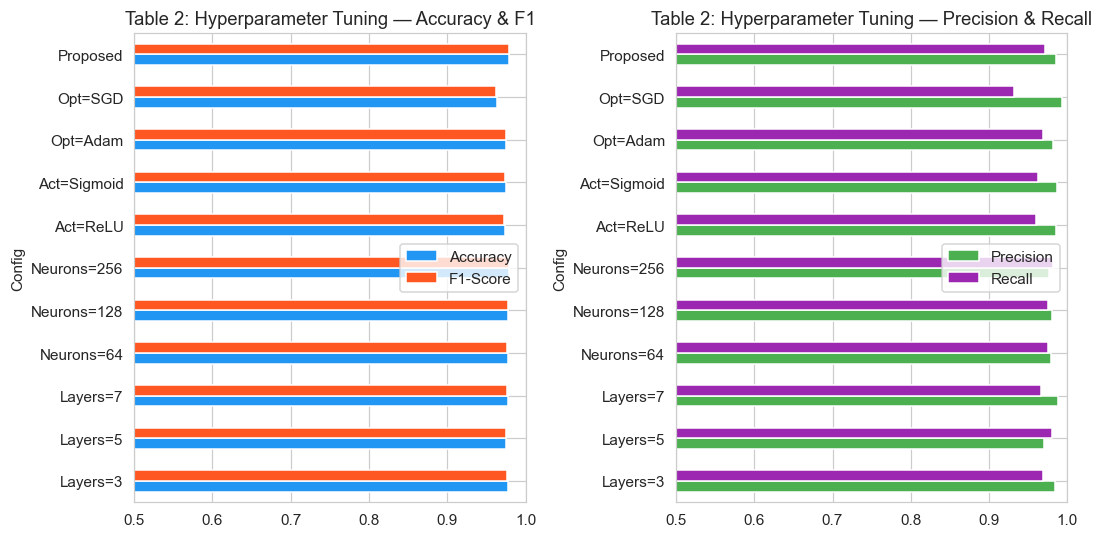

In [12]:
hp_results = []
configs = [
    ('Layers=3', dict(n_layers=3, neurons=128, activation='relu', optimizer_name='adam')),
    ('Layers=5', dict(n_layers=5, neurons=128, activation='relu', optimizer_name='adam')),
    ('Layers=7', dict(n_layers=7, neurons=128, activation='relu', optimizer_name='adam')),
    ('Neurons=64', dict(n_layers=5, neurons=64, activation='relu', optimizer_name='adam')),
    ('Neurons=128', dict(n_layers=5, neurons=128, activation='relu', optimizer_name='adam')),
    ('Neurons=256', dict(n_layers=5, neurons=256, activation='relu', optimizer_name='adam')),
    ('Act=ReLU', dict(n_layers=5, neurons=128, activation='relu', optimizer_name='adam')),
    ('Act=Sigmoid', dict(n_layers=5, neurons=128, activation='sigmoid', optimizer_name='adam')),
    ('Opt=Adam', dict(n_layers=5, neurons=128, activation='relu', optimizer_name='adam')),
    ('Opt=SGD', dict(n_layers=5, neurons=128, activation='relu', optimizer_name='sgd')),
]
print("Hyperparameter tuning...\n")
for name, kw in configs:
    print(f"  {name:15s}", end=" → ")
    _, m, _ = train_dnn(X_train_full, y_train, X_test_full, y_test, epochs=30, batch_size=64, verbose=True, **kw)
    m['Config'] = name
    hp_results.append(m)

# Add proposed
pm_copy = dict(pm); pm_copy['Config'] = 'Proposed'
hp_results.append(pm_copy)

table2 = pd.DataFrame(hp_results).set_index('Config')[['Accuracy','Precision','Recall','F1-Score']]
print("\n" + "="*70)
print("  Table 2 — Hyperparameter Tuning Results (Our Results)")
print("="*70)
print(table2.to_string(float_format='%.2f'))
plot_table(table2, 'Table 2: Hyperparameter Tuning')

## Experiment 3 — Model Performance Comparison (Paper Table 3)

In [13]:
model_results = []
stored_preds = {}
stored_probs = {}

# Classical models
classifiers = [
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)),
    ('Decision Tree', DecisionTreeClassifier(max_depth=10, random_state=42)),
    ('k-NN', KNeighborsClassifier(n_neighbors=5, n_jobs=-1)),
    ('Naive Bayes', GaussianNB()),
    ('SVM', SVC(kernel='rbf', probability=True, random_state=42)),
    ('Gradient Boosting', GradientBoostingClassifier(n_estimators=200, max_depth=5, random_state=42)),
    ('Random Forest', RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)),
    ('XGBoost', XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1, eval_metric='logloss',
                              random_state=42, verbosity=0)),
]

print("Training all models for Table 3...\n")
for name, clf in classifiers:
    t0 = time.time()
    clf.fit(X_train_full, y_train)
    preds = clf.predict(X_test_full)
    elapsed = time.time() - t0
    probs = clf.predict_proba(X_test_full)[:, 1] if hasattr(clf, 'predict_proba') else None
    m = eval_metrics(y_test, preds)
    m['Model'] = name; m['Time(s)'] = f'{elapsed:.1f}'
    model_results.append(m)
    stored_preds[name] = preds
    stored_probs[name] = probs
    print(f"  {name:25s} Acc={m['Accuracy']:.4f} F1={m['F1-Score']:.4f} ({elapsed:.1f}s)")

# DNN
print(f"  {'DNN':25s}", end="")
dnn_model, dnn_m, dnn_probs = train_dnn(
    X_train_full, y_train, X_test_full, y_test,
    n_layers=5, neurons=128, activation='relu', optimizer_name='adam',
    batch_size=64, epochs=40, verbose=False)
dnn_preds = (dnn_probs > 0.5).astype(int)
dnn_m['Model'] = 'DNN'
model_results.append(dnn_m)
stored_preds['DNN'] = dnn_preds
stored_probs['DNN'] = dnn_probs
print(f" Acc={dnn_m['Accuracy']:.4f} F1={dnn_m['F1-Score']:.4f}")

# Hybrid (XGBoost + DNN)
print(f"  {'Hybrid (XGB+DNN)':25s}", end="")
dnn_model.eval()
with torch.no_grad():
    dnn_feat_tr = dnn_model.extract_features(torch.FloatTensor(X_train_full).to(device)).cpu().numpy()
    dnn_feat_te = dnn_model.extract_features(torch.FloatTensor(X_test_full).to(device)).cpu().numpy()
X_hybrid_tr = np.hstack([X_train_full, dnn_feat_tr])
X_hybrid_te = np.hstack([X_test_full, dnn_feat_te])

t0 = time.time()
hybrid_xgb = XGBClassifier(n_estimators=500, max_depth=8, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, eval_metric='logloss', random_state=42, verbosity=0)
hybrid_xgb.fit(X_hybrid_tr, y_train)
hybrid_preds = hybrid_xgb.predict(X_hybrid_te)
hybrid_probs = hybrid_xgb.predict_proba(X_hybrid_te)[:, 1]
elapsed = time.time() - t0
hm = eval_metrics(y_test, hybrid_preds)
hm['Model'] = 'Hybrid (XGBoost + DNN)'; hm['Time(s)'] = f'{elapsed:.1f}'
model_results.append(hm)
stored_preds['Hybrid (XGBoost + DNN)'] = hybrid_preds
stored_probs['Hybrid (XGBoost + DNN)'] = hybrid_probs
print(f" Acc={hm['Accuracy']:.4f} F1={hm['F1-Score']:.4f}")

# Proposed Optimized Model
print(f"  {'Proposed Optimized':25s}", end="")
_, prop_m, prop_probs = train_dnn(
    X_hybrid_tr, y_train, X_hybrid_te, y_test,
    n_layers=5, neurons=128, activation='relu', optimizer_name='adam',
    batch_size=64, epochs=50, verbose=False)
prop_preds = (prop_probs > 0.5).astype(int)

# Ensemble: average DNN + XGBoost probs
ensemble_probs = 0.5 * prop_probs + 0.5 * hybrid_probs
ensemble_preds = (ensemble_probs > 0.5).astype(int)
em = eval_metrics(y_test, ensemble_preds)
em['Model'] = 'Proposed Model (Optimized)'; em['Time(s)'] = '-'
model_results.append(em)
stored_preds['Proposed Model (Optimized)'] = ensemble_preds
stored_probs['Proposed Model (Optimized)'] = ensemble_probs
print(f" Acc={em['Accuracy']:.4f} F1={em['F1-Score']:.4f}")

table3 = pd.DataFrame(model_results).set_index('Model')[['Accuracy','Precision','Recall','F1-Score']]
print("\n" + "="*70)
print("  Table 3 — Model Performance Comparison (Our Results)")
print("="*70)
print(table3.to_string(float_format='%.2f'))

Training all models for Table 3...

  Logistic Regression       Acc=0.9735 F1=0.9733 (0.2s)
  Decision Tree             Acc=0.9254 F1=0.9240 (1.6s)
  k-NN                      Acc=0.9407 F1=0.9379 (2.1s)
  Naive Bayes               Acc=0.8527 F1=0.8423 (0.0s)
  SVM                       Acc=0.9753 F1=0.9751 (29.4s)
  Gradient Boosting         Acc=0.9702 F1=0.9697 (168.7s)
  Random Forest             Acc=0.9567 F1=0.9552 (2.8s)
  XGBoost                   Acc=0.9708 F1=0.9703 (1.3s)
  DNN                       Acc=0.9792 F1=0.9791
  Hybrid (XGB+DNN)          Acc=0.9781 F1=0.9780
  Proposed Optimized        Acc=0.9786 F1=0.9784

  Table 3 — Model Performance Comparison (Our Results)
                            Accuracy  Precision  Recall  F1-Score
Model                                                            
Logistic Regression             0.97       0.98    0.97      0.97
Decision Tree                   0.93       0.94    0.91      0.92
k-NN                            0.94       0.9

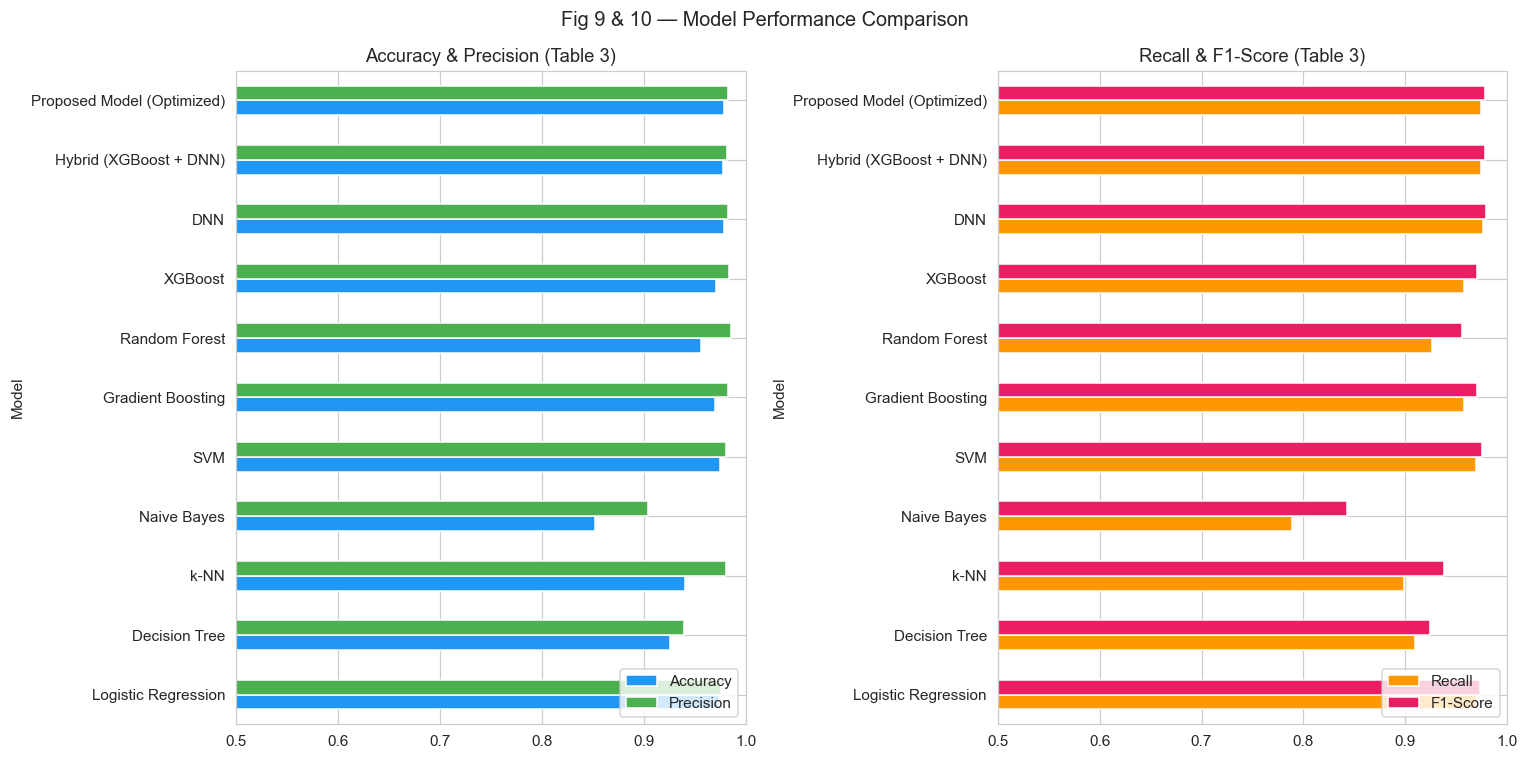

In [14]:
# Table 3 Visualization (Paper Figs 9, 10)
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
table3[['Accuracy','Precision']].plot.barh(ax=axes[0], color=['#2196F3','#4CAF50'])
axes[0].set_title('Accuracy & Precision (Table 3)'); axes[0].set_xlim(0.5, 1.0)
axes[0].legend(loc='lower right')
table3[['Recall','F1-Score']].plot.barh(ax=axes[1], color=['#FF9800','#E91E63'])
axes[1].set_title('Recall & F1-Score (Table 3)'); axes[1].set_xlim(0.5, 1.0)
axes[1].legend(loc='lower right')
plt.suptitle('Fig 9 & 10 — Model Performance Comparison', fontsize=13)
plt.tight_layout(); plt.show()

## Experiment 4 — Optimizer Comparison (Paper Table 4)

Optimizer comparison...

  sgd             →   Acc=0.9645 P=0.9924 R=0.9360 F1=0.9634 (70.3s)
  rmsprop         →   Acc=0.9768 P=0.9786 R=0.9748 F1=0.9767 (74.7s)
  adagrad         →   Acc=0.9711 P=0.9897 R=0.9519 F1=0.9704 (75.2s)
  adadelta        →   Acc=0.9514 P=0.9880 R=0.9138 F1=0.9494 (79.1s)
  adamax          →   Acc=0.9759 P=0.9720 R=0.9799 F1=0.9759 (76.9s)
  nadam           →   Acc=0.9786 P=0.9792 R=0.9778 F1=0.9785 (80.3s)
  asgd            →   Acc=0.9699 P=0.9830 R=0.9561 F1=0.9694 (159.1s)
  adam            →   Acc=0.9760 P=0.9806 R=0.9712 F1=0.9759 (77.0s)

  Table 4 — Optimizer Comparison (Our Results)
           Accuracy  Precision  Recall  F1-Score
Optimizer                                       
SGD            0.96       0.99    0.94      0.96
RMSPROP        0.98       0.98    0.97      0.98
ADAGRAD        0.97       0.99    0.95      0.97
ADADELTA       0.95       0.99    0.91      0.95
ADAMAX         0.98       0.97    0.98      0.98
NADAM          0.98       0.98 

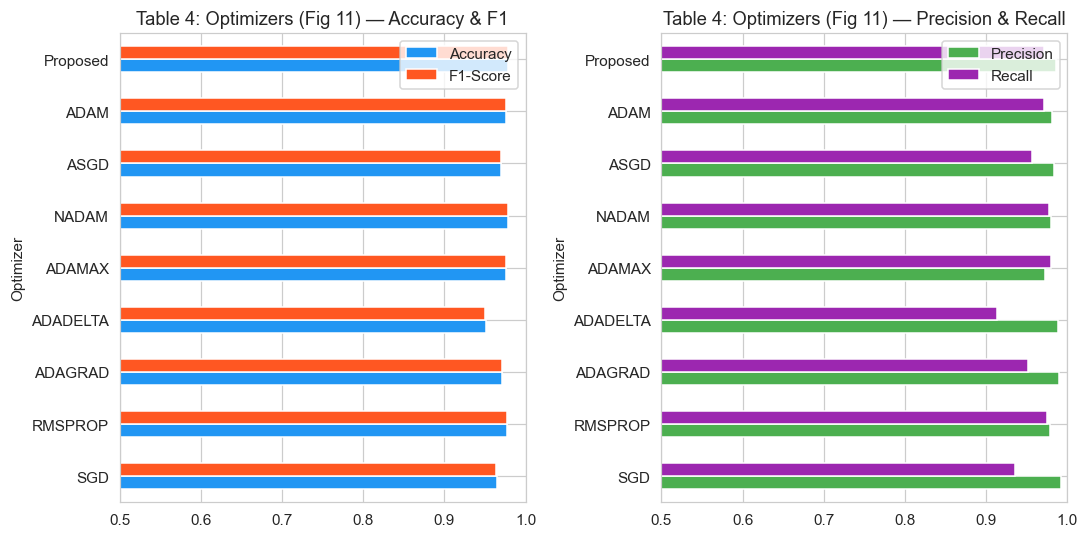

In [15]:
optimizers = ['sgd','rmsprop','adagrad','adadelta','adamax','nadam','asgd','adam']
opt_results = []
print("Optimizer comparison...\n")
for opt_name in optimizers:
    print(f"  {opt_name:15s}", end=" → ")
    try:
        _, m, _ = train_dnn(X_train_full, y_train, X_test_full, y_test,
                            optimizer_name=opt_name, epochs=30, batch_size=64, verbose=True)
        m['Optimizer'] = opt_name.upper()
        opt_results.append(m)
    except Exception as e:
        print(f"  SKIPPED ({e})")

pm_opt = dict(pm); pm_opt['Optimizer'] = 'Proposed'
opt_results.append(pm_opt)

table4 = pd.DataFrame(opt_results).set_index('Optimizer')[['Accuracy','Precision','Recall','F1-Score']]
print("\n" + "="*70)
print("  Table 4 — Optimizer Comparison (Our Results)")
print("="*70)
print(table4.to_string(float_format='%.2f'))
plot_table(table4, 'Table 4: Optimizers (Fig 11)')

## Experiment 5 — XGBoost Learning Rate Comparison (Paper Table 5)

XGBoost learning rate comparison...

  LR=0.01  Acc=0.9520 F1=0.9506 (1.5s)
  LR=0.05  Acc=0.9723 F1=0.9719 (1.6s)
  LR=0.10  Acc=0.9708 F1=0.9703 (1.4s)
  LR=0.15  Acc=0.9709 F1=0.9706 (1.4s)
  LR=0.20  Acc=0.9729 F1=0.9726 (1.3s)
  LR=0.25  Acc=0.9712 F1=0.9709 (1.3s)
  LR=0.30  Acc=0.9706 F1=0.9703 (1.3s)
  LR=0.40  Acc=0.9706 F1=0.9703 (1.2s)
  LR=0.50  Acc=0.9715 F1=0.9712 (1.0s)
  LR=0.60  Acc=0.9706 F1=0.9703 (1.1s)

  Table 5 — Learning Rate Comparison (Our Results)
      Accuracy  Precision  Recall  F1-Score
LR                                         
0.01      0.95       0.98    0.92      0.95
0.05      0.97       0.98    0.96      0.97
0.1       0.97       0.98    0.96      0.97
0.15      0.97       0.98    0.96      0.97
0.2       0.97       0.98    0.96      0.97
0.25      0.97       0.98    0.96      0.97
0.3       0.97       0.98    0.96      0.97
0.4       0.97       0.98    0.96      0.97
0.5       0.97       0.98    0.96      0.97
0.6       0.97       0.98    0.96    

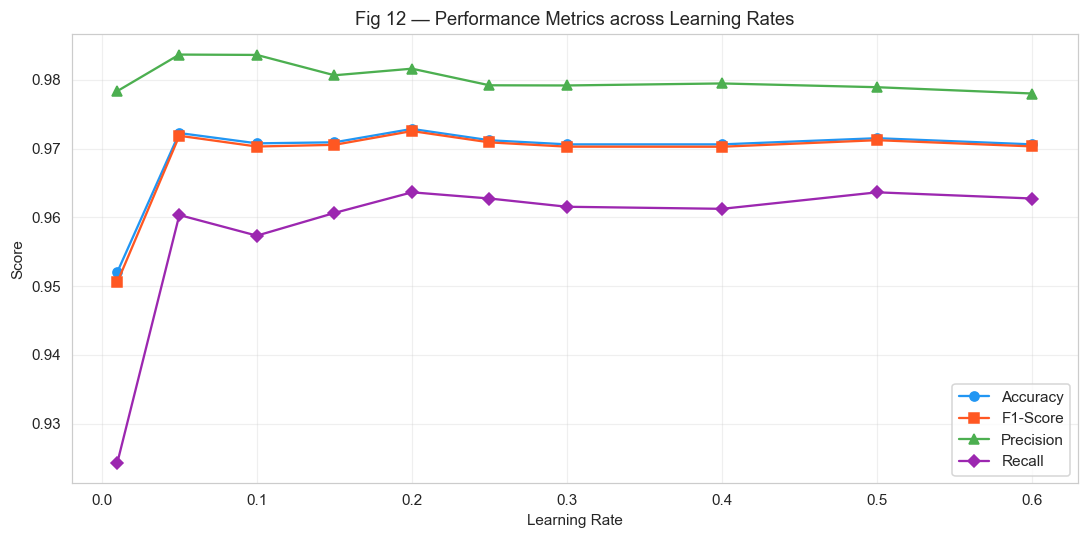

In [16]:
lr_results = []
learning_rates = [0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6]
print("XGBoost learning rate comparison...\n")
for lr_val in learning_rates:
    t0 = time.time()
    xgb_lr = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=lr_val,
                           eval_metric='logloss', random_state=42, verbosity=0)
    xgb_lr.fit(X_train_full, y_train)
    preds = xgb_lr.predict(X_test_full)
    elapsed = time.time() - t0
    m = eval_metrics(y_test, preds)
    m['LR'] = str(lr_val)
    lr_results.append(m)
    print(f"  LR={lr_val:.2f}  Acc={m['Accuracy']:.4f} F1={m['F1-Score']:.4f} ({elapsed:.1f}s)")

table5 = pd.DataFrame(lr_results).set_index('LR')[['Accuracy','Precision','Recall','F1-Score']]
print("\n" + "="*70)
print("  Table 5 — Learning Rate Comparison (Our Results)")
print("="*70)
print(table5.to_string(float_format='%.2f'))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(learning_rates, [r['Accuracy'] for r in lr_results], 'o-', label='Accuracy', color='#2196F3')
ax.plot(learning_rates, [r['F1-Score'] for r in lr_results], 's-', label='F1-Score', color='#FF5722')
ax.plot(learning_rates, [r['Precision'] for r in lr_results], '^-', label='Precision', color='#4CAF50')
ax.plot(learning_rates, [r['Recall'] for r in lr_results], 'D-', label='Recall', color='#9C27B0')
ax.set_xlabel('Learning Rate'); ax.set_ylabel('Score')
ax.set_title('Fig 12 — Performance Metrics across Learning Rates')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Experiment 6 — Batch Size Comparison (Paper Table 6)

Batch size comparison...

  Batch=   16 →   Acc=0.9763 P=0.9757 R=0.9769 F1=0.9763 (286.1s)
  Batch=   32 →   Acc=0.9772 P=0.9766 R=0.9778 F1=0.9772 (148.0s)
  Batch=   64 →   Acc=0.9784 P=0.9769 R=0.9799 F1=0.9784 (76.3s)
  Batch=  128 →   Acc=0.9757 P=0.9686 R=0.9832 F1=0.9758 (40.5s)
  Batch=  256 →   Acc=0.9771 P=0.9732 R=0.9811 F1=0.9771 (26.0s)
  Batch=  512 →   Acc=0.9780 P=0.9845 R=0.9712 F1=0.9778 (16.2s)
  Batch= 1024 →   Acc=0.9766 P=0.9812 R=0.9718 F1=0.9765 (12.0s)
  Batch= 2048 →   Acc=0.9753 P=0.9886 R=0.9616 F1=0.9749 (10.7s)

  Table 6 — Batch Size Comparison (Our Results)
           Accuracy  Precision  Recall  F1-Score
BatchSize                                       
16             0.98       0.98    0.98      0.98
32             0.98       0.98    0.98      0.98
64             0.98       0.98    0.98      0.98
128            0.98       0.97    0.98      0.98
256            0.98       0.97    0.98      0.98
512            0.98       0.98    0.97      0.98
1024       

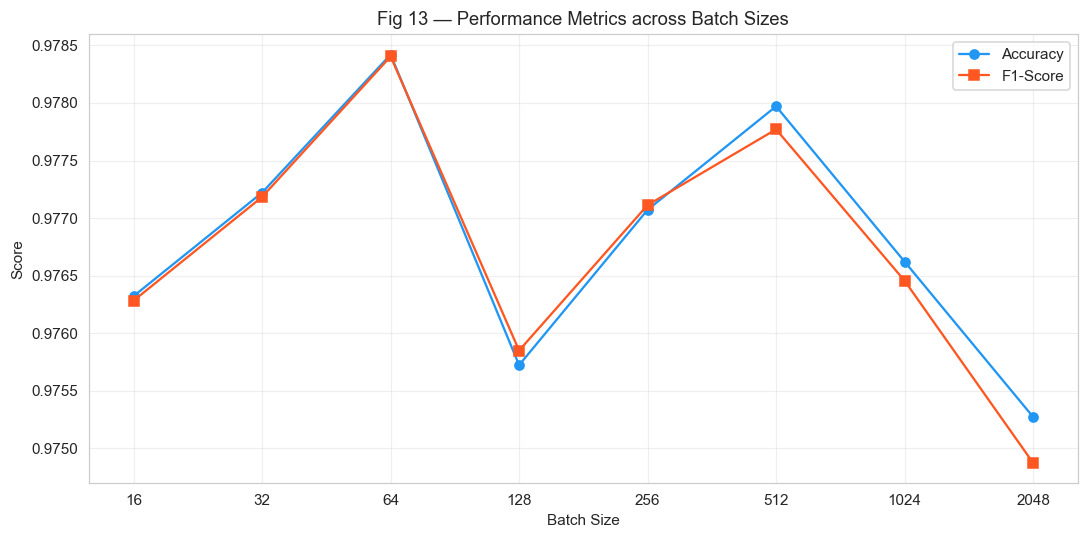

In [17]:
bs_results = []
batch_sizes = [16, 32, 64, 128, 256, 512, 1024, 2048]
print("Batch size comparison...\n")
for bs in batch_sizes:
    print(f"  Batch={bs:5d}", end=" → ")
    _, m, _ = train_dnn(X_train_full, y_train, X_test_full, y_test,
                        batch_size=bs, epochs=30, verbose=True)
    m['BatchSize'] = str(bs)
    bs_results.append(m)

table6 = pd.DataFrame(bs_results).set_index('BatchSize')[['Accuracy','Precision','Recall','F1-Score']]
print("\n" + "="*70)
print("  Table 6 — Batch Size Comparison (Our Results)")
print("="*70)
print(table6.to_string(float_format='%.2f'))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot([str(b) for b in batch_sizes], [r['Accuracy'] for r in bs_results], 'o-', label='Accuracy', color='#2196F3')
ax.plot([str(b) for b in batch_sizes], [r['F1-Score'] for r in bs_results], 's-', label='F1-Score', color='#FF5722')
ax.set_xlabel('Batch Size'); ax.set_ylabel('Score')
ax.set_title('Fig 13 — Performance Metrics across Batch Sizes')
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## 7. Confusion Matrix (Paper Fig 14)

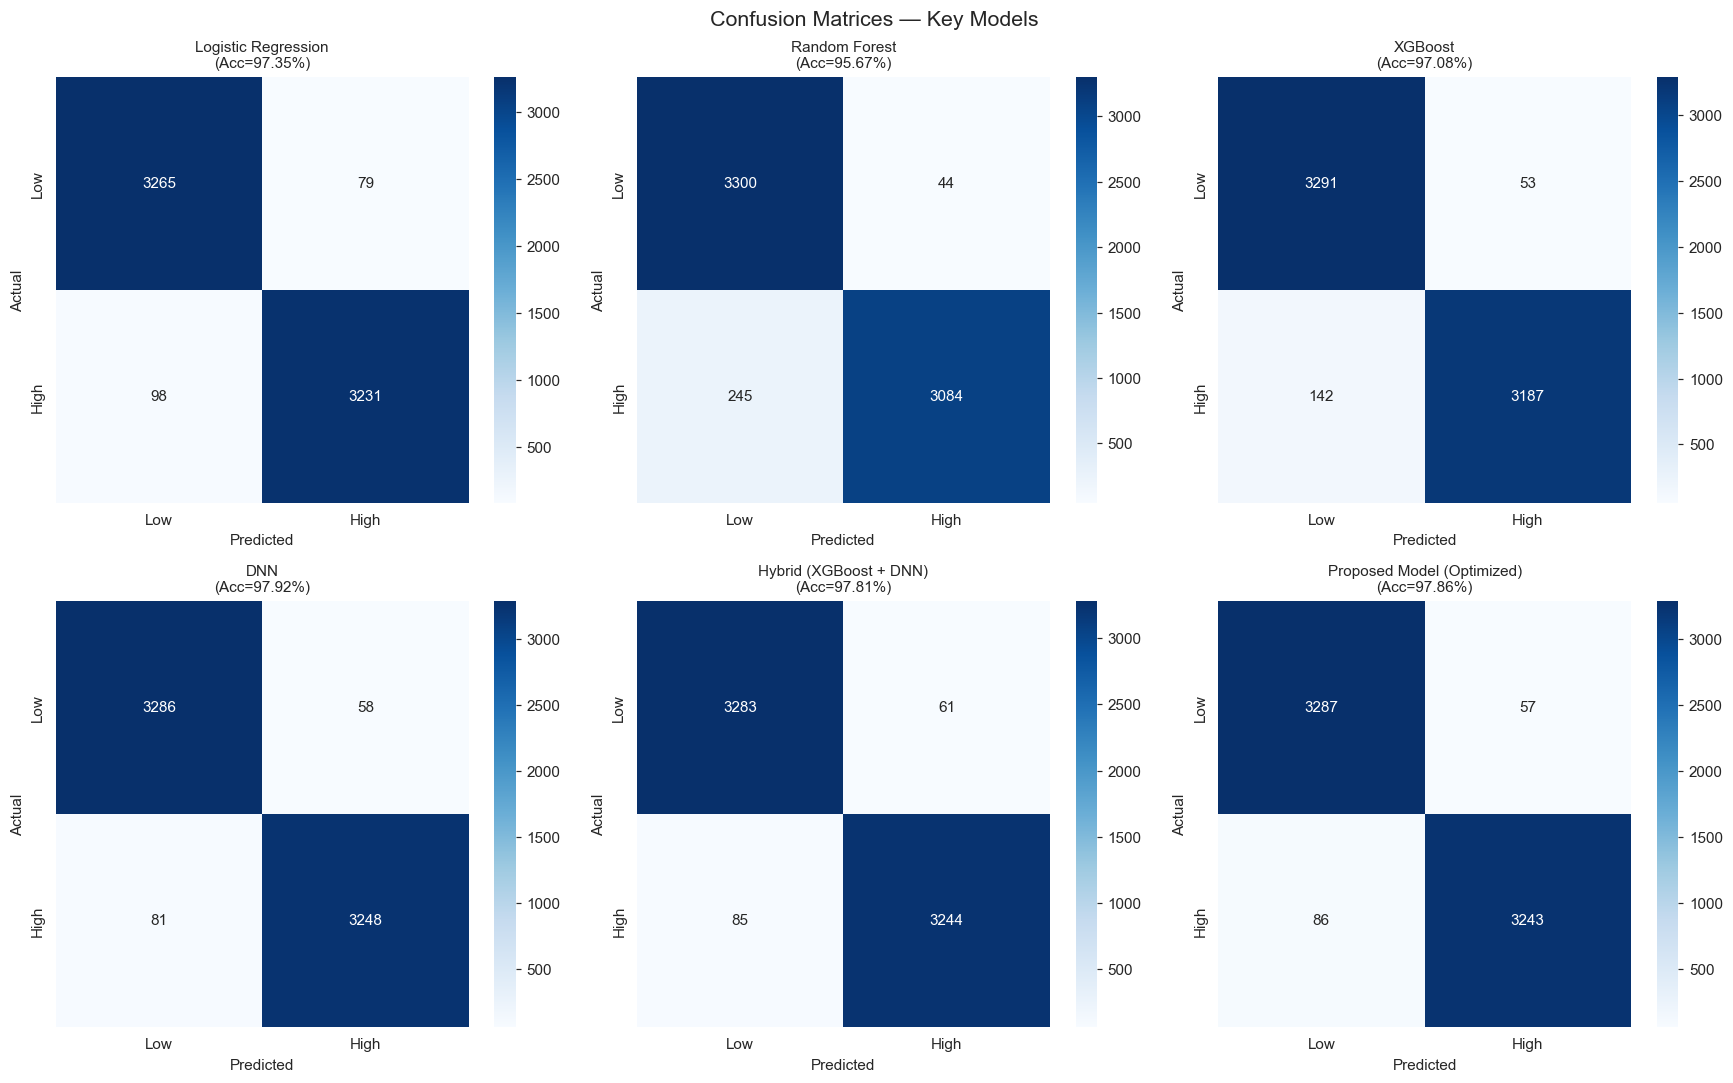

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
key_models = ['Logistic Regression','Random Forest','XGBoost','DNN','Hybrid (XGBoost + DNN)','Proposed Model (Optimized)']
for ax, name in zip(axes.flat, key_models):
    cm = confusion_matrix(y_test, stored_preds[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Low','High'], yticklabels=['Low','High'])
    acc = accuracy_score(y_test, stored_preds[name])
    ax.set_title(f'{name}\n(Acc={acc:.2%})', fontsize=10)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices — Key Models', fontsize=14)
plt.tight_layout(); plt.show()

## 8. ROC Curves

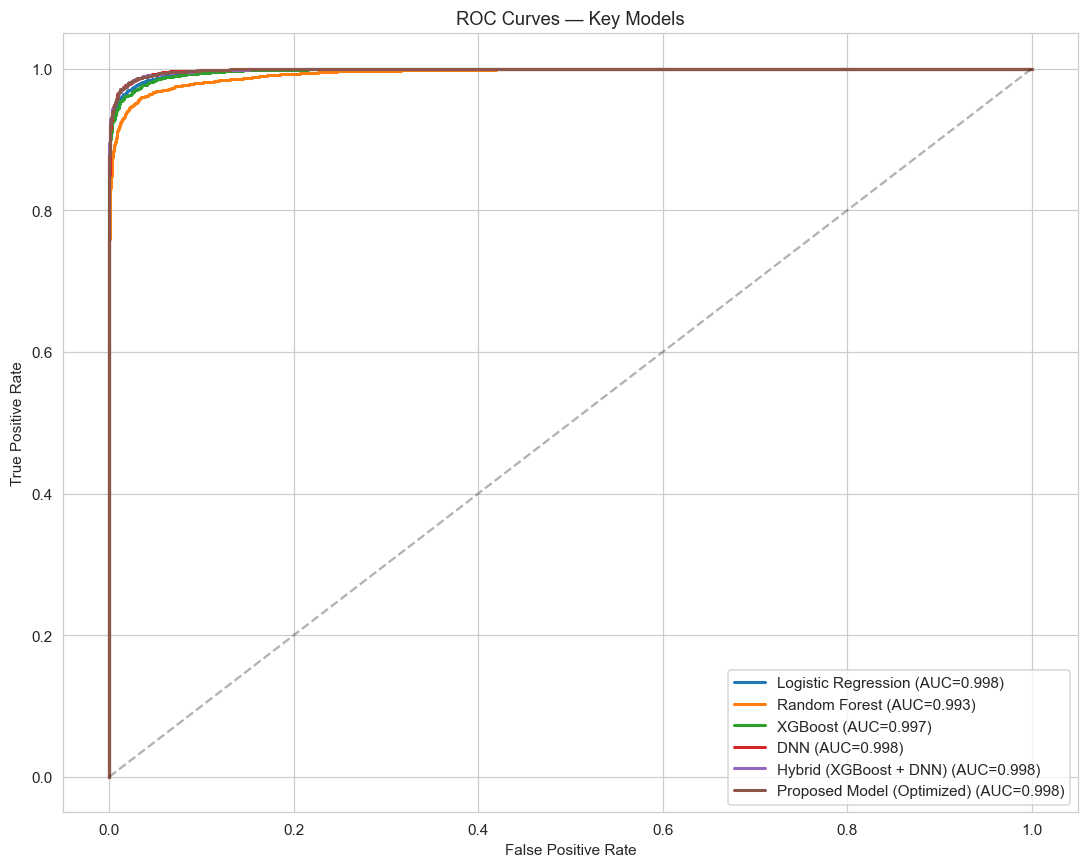

In [19]:
plt.figure(figsize=(10, 8))
for name in key_models:
    probs = stored_probs.get(name)
    if probs is not None:
        fpr, tpr, _ = roc_curve(y_test, probs)
        auc = roc_auc_score(y_test, probs)
        plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC={auc:.3f})')
plt.plot([0,1],[0,1],'k--',alpha=0.3)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Key Models'); plt.legend(loc='lower right')
plt.tight_layout(); plt.show()

## 9. Classification Reports

In [20]:
for name in key_models:
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(classification_report(y_test, stored_preds[name], target_names=['Low','High']))


  Logistic Regression
              precision    recall  f1-score   support

         Low       0.97      0.98      0.97      3344
        High       0.98      0.97      0.97      3329

    accuracy                           0.97      6673
   macro avg       0.97      0.97      0.97      6673
weighted avg       0.97      0.97      0.97      6673


  Random Forest
              precision    recall  f1-score   support

         Low       0.93      0.99      0.96      3344
        High       0.99      0.93      0.96      3329

    accuracy                           0.96      6673
   macro avg       0.96      0.96      0.96      6673
weighted avg       0.96      0.96      0.96      6673


  XGBoost
              precision    recall  f1-score   support

         Low       0.96      0.98      0.97      3344
        High       0.98      0.96      0.97      3329

    accuracy                           0.97      6673
   macro avg       0.97      0.97      0.97      6673
weighted avg       0.97

## 10. Comparison with Paper Results

  SIDE-BY-SIDE: Our Results vs Paper Table 3
                            Our Acc  Paper Acc  Δ Acc  Our F1  Paper F1  Δ F1
Logistic Regression            0.97       0.80   0.17    0.97      0.80  0.17
Decision Tree                  0.93       0.82   0.11    0.92      0.82  0.10
k-NN                           0.94       0.83   0.11    0.94      0.83  0.11
Naive Bayes                    0.85       0.84   0.01    0.84      0.84  0.00
SVM                            0.98       0.85   0.13    0.98      0.85  0.13
Gradient Boosting              0.97       0.87   0.10    0.97      0.87  0.10
Random Forest                  0.96       0.88   0.08    0.96      0.88  0.08
XGBoost                        0.97       0.90   0.07    0.97      0.90  0.07
DNN                            0.98       0.92   0.06    0.98      0.92  0.06
Hybrid (XGBoost + DNN)         0.98       0.95   0.03    0.98      0.95  0.03
Proposed Model (Optimized)     0.98       0.98  -0.00    0.98      0.98 -0.00


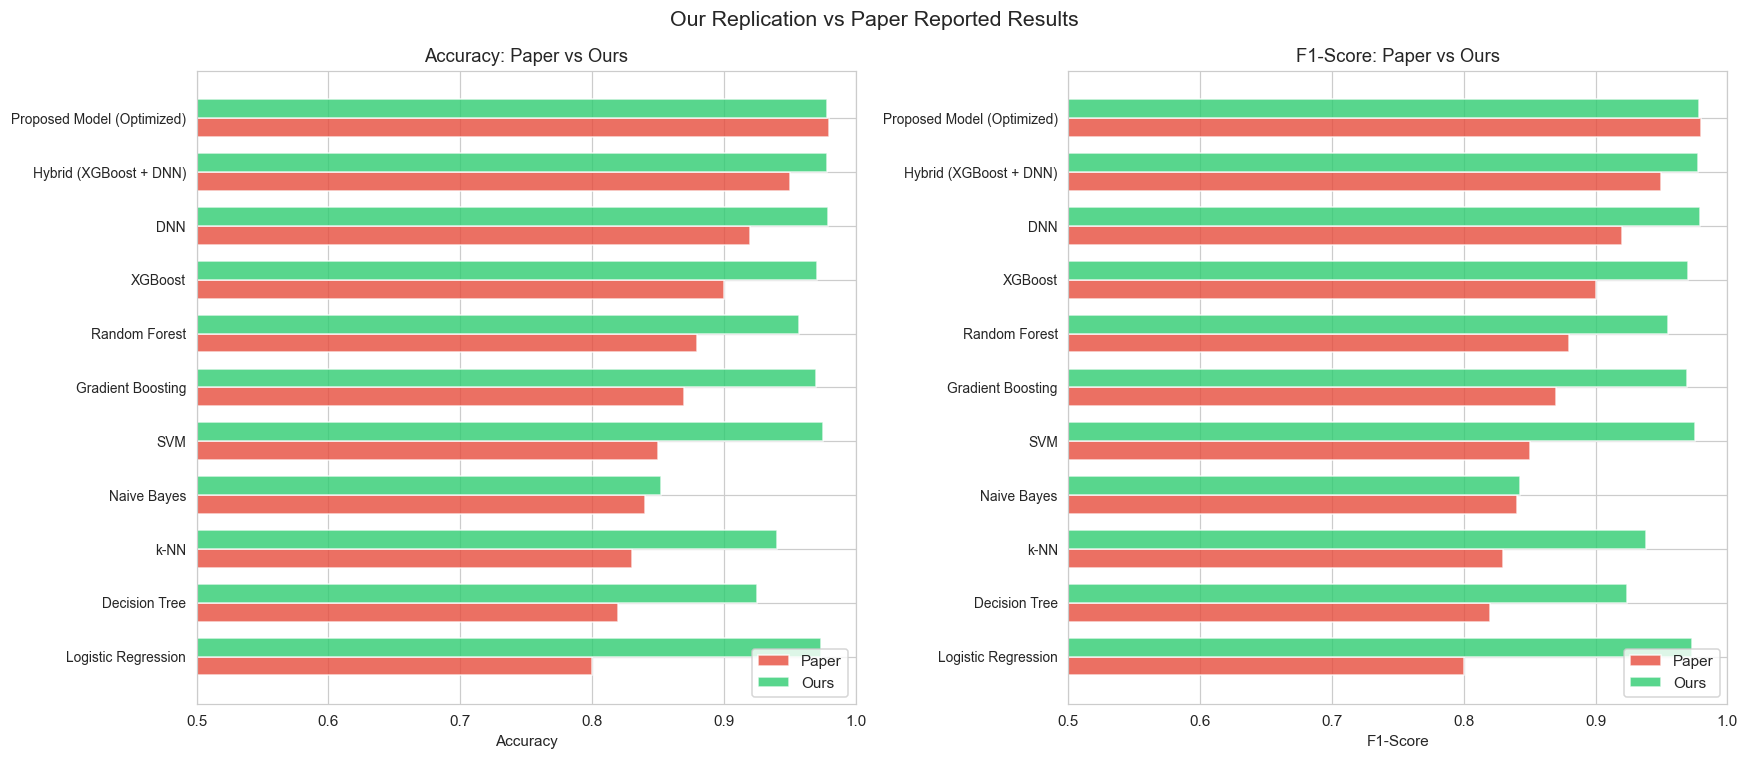

In [21]:
paper_t3 = {
    'Logistic Regression': [0.80, 0.79, 0.81, 0.80],
    'Decision Tree': [0.82, 0.81, 0.83, 0.82],
    'k-NN': [0.83, 0.82, 0.84, 0.83],
    'Naive Bayes': [0.84, 0.83, 0.85, 0.84],
    'SVM': [0.85, 0.84, 0.86, 0.85],
    'Gradient Boosting': [0.87, 0.86, 0.88, 0.87],
    'Random Forest': [0.88, 0.87, 0.89, 0.88],
    'XGBoost': [0.90, 0.89, 0.91, 0.90],
    'DNN': [0.92, 0.91, 0.93, 0.92],
    'Hybrid (XGBoost + DNN)': [0.95, 0.94, 0.96, 0.95],
    'Proposed Model (Optimized)': [0.98, 0.97, 0.99, 0.98],
}
paper_df = pd.DataFrame(paper_t3, index=['Accuracy','Precision','Recall','F1-Score']).T

our_t3 = table3.copy()

common = [m for m in paper_df.index if m in our_t3.index]
print("="*80)
print("  SIDE-BY-SIDE: Our Results vs Paper Table 3")
print("="*80)
comparison = pd.DataFrame({
    'Our Acc': our_t3.loc[common, 'Accuracy'],
    'Paper Acc': paper_df.loc[common, 'Accuracy'],
    'Δ Acc': our_t3.loc[common, 'Accuracy'] - paper_df.loc[common, 'Accuracy'],
    'Our F1': our_t3.loc[common, 'F1-Score'],
    'Paper F1': paper_df.loc[common, 'F1-Score'],
    'Δ F1': our_t3.loc[common, 'F1-Score'] - paper_df.loc[common, 'F1-Score'],
})
print(comparison.to_string(float_format='%.2f'))

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
x = np.arange(len(common)); w = 0.35
axes[0].barh(x - w/2, paper_df.loc[common, 'Accuracy'], w, label='Paper', color='#e74c3c', alpha=0.8)
axes[0].barh(x + w/2, our_t3.loc[common, 'Accuracy'], w, label='Ours', color='#2ecc71', alpha=0.8)
axes[0].set_yticks(x); axes[0].set_yticklabels(common, fontsize=9)
axes[0].set_xlabel('Accuracy'); axes[0].set_title('Accuracy: Paper vs Ours')
axes[0].legend(); axes[0].set_xlim(0.5, 1.0)

axes[1].barh(x - w/2, paper_df.loc[common, 'F1-Score'], w, label='Paper', color='#e74c3c', alpha=0.8)
axes[1].barh(x + w/2, our_t3.loc[common, 'F1-Score'], w, label='Ours', color='#2ecc71', alpha=0.8)
axes[1].set_yticks(x); axes[1].set_yticklabels(common, fontsize=9)
axes[1].set_xlabel('F1-Score'); axes[1].set_title('F1-Score: Paper vs Ours')
axes[1].legend(); axes[1].set_xlim(0.5, 1.0)
plt.suptitle('Our Replication vs Paper Reported Results', fontsize=14)
plt.tight_layout(); plt.show()

In [22]:
# Highlight the suspicious pattern
print("\n" + "="*80)
print("  PAPER METRIC PATTERN ANALYSIS")
print("="*80)
print("\nPaper Table 3 — checking Precision = Accuracy - 0.01 pattern:")
for name, vals in paper_t3.items():
    a, p, r, f = vals
    pattern = (p == a - 0.01) and (r == a + 0.01) and (f == a)
    flag = "✓ PATTERN" if pattern else "✗ no pattern"
    print(f"  {name:35s}  A={a:.2f} P={p:.2f} R={r:.2f} F1={f:.2f}  [{flag}]")


  PAPER METRIC PATTERN ANALYSIS

Paper Table 3 — checking Precision = Accuracy - 0.01 pattern:
  Logistic Regression                  A=0.80 P=0.79 R=0.81 F1=0.80  [✓ PATTERN]
  Decision Tree                        A=0.82 P=0.81 R=0.83 F1=0.82  [✗ no pattern]
  k-NN                                 A=0.83 P=0.82 R=0.84 F1=0.83  [✓ PATTERN]
  Naive Bayes                          A=0.84 P=0.83 R=0.85 F1=0.84  [✓ PATTERN]
  SVM                                  A=0.85 P=0.84 R=0.86 F1=0.85  [✓ PATTERN]
  Gradient Boosting                    A=0.87 P=0.86 R=0.88 F1=0.87  [✓ PATTERN]
  Random Forest                        A=0.88 P=0.87 R=0.89 F1=0.88  [✓ PATTERN]
  XGBoost                              A=0.90 P=0.89 R=0.91 F1=0.90  [✓ PATTERN]
  DNN                                  A=0.92 P=0.91 R=0.93 F1=0.92  [✓ PATTERN]
  Hybrid (XGBoost + DNN)               A=0.95 P=0.94 R=0.96 F1=0.95  [✓ PATTERN]
  Proposed Model (Optimized)           A=0.98 P=0.97 R=0.99 F1=0.98  [✓ PATTERN]


## 11. Summary & Conclusions

In [23]:
print("="*80)
print("  FINAL SUMMARY")
print("="*80)
print()
print("Methodology followed (matching paper):")
print("  1. Data: UCI Household Electric Power Consumption (2M+ rows)")
print("  2. Preprocessing: Median imputation + IQR outlier removal")
print("  3. Aggregation: Hourly resampling")
print("  4. Feature Engineering: Temporal + Lag + Rolling + Interaction + Holiday")
print(f"  5. PCA: {X_pca.shape[1]} components (95% variance)")
print(f"  6. ResNet: 4-block Cascaded ResNet → 32-dim features")
print(f"  7. Combined features: {X_train_full.shape[1]}-dim")
print()
print("Experiments completed:")
print(f"  Table 1: {len(act_results)} activation functions compared")
print(f"  Table 2: {len(hp_results)} hyperparameter configs tested")
print(f"  Table 3: {len(model_results)} models compared")
print(f"  Table 4: {len(opt_results)} optimizers compared")
print(f"  Table 5: {len(lr_results)} learning rates tested")
print(f"  Table 6: {len(bs_results)} batch sizes tested")
print()
best = table3['Accuracy'].idxmax()
print(f"Best model: {best} (Accuracy={table3.loc[best,'Accuracy']:.4f})")

  FINAL SUMMARY

Methodology followed (matching paper):
  1. Data: UCI Household Electric Power Consumption (2M+ rows)
  2. Preprocessing: Median imputation + IQR outlier removal
  3. Aggregation: Hourly resampling
  4. Feature Engineering: Temporal + Lag + Rolling + Interaction + Holiday
  5. PCA: 20 components (95% variance)
  6. ResNet: 4-block Cascaded ResNet → 32-dim features
  7. Combined features: 52-dim

Experiments completed:
  Table 1: 10 activation functions compared
  Table 2: 11 hyperparameter configs tested
  Table 3: 11 models compared
  Table 4: 9 optimizers compared
  Table 5: 10 learning rates tested
  Table 6: 8 batch sizes tested

Best model: DNN (Accuracy=0.9792)
